# Proyecto Aplicado MIAD G8


## Librerias y Importacion de Datos

In [ ]:
# Descarga del archivo
!gdown "https://drive.google.com/drive/u/1/folders/1URIsODJLj-pOH-HCpK2td5T00ycEju2n"

/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://drive.google.com/drive/u/1/folders/1URIsODJLj-pOH-HCpK2td5T00ycEju2n
To: /content/1URIsODJLj-pOH-HCpK2td5T00ycEju2n
1.21MB [00:00, 5.53MB/s]


In [ ]:
# Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score,auc, confusion_matrix, f1_score,make_scorer
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

In [ ]:
# Importacion de los datos
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

ruta = '/content/drive/MyDrive/MIAD PROYECTO APLICADO GUERREROS/Bases de Datos/Colisiones_BogV1.csv'
df = pd.read_csv(ruta, sep=';')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID_COL,COLYEAR,COLMONTH,COLDAY,COLHOUR,COLMIN,COLSEV,COLTYP,COLOBJ,COLOBJTYP,COLSDESIGN,COLVICNUM,Fecha,TEMP MEAN,PSUM LLUVIA SEM,PROM DIA LLUVIA
0,10446658,2018,5,3,12,15,3,1,1.0,NaN,2,2.0,3/05/2018,"13,81","28,99","4,14"
1,10446659,2018,4,30,8,0,3,1,1.0,NaN,1,2.0,30/04/2018,"13,81","28,99","4,14"
2,10446660,2018,5,3,13,15,3,1,1.0,NaN,1,2.0,3/05/2018,"13,81","28,99","4,14"
3,10446661,2018,4,30,7,55,3,1,1.0,NaN,1,2.0,30/04/2018,"13,81","28,99","4,14"
4,10446662,2018,5,3,7,30,3,1,1.0,NaN,1,2.0,3/05/2018,"13,81","28,99","4,14"


Se cambian los nombres de las variables para mayor claridad según diccionario:
- ID_COL → **ID:** Número de serie único del choque.
- COLYEAR → **Año:** Año en que ocurrió la colisión.
- COLMONTH → **Mes:** Mes en que ocurrió la colisión.
- COLDAY → **Día:** Día en que ocurrió la colisión.
- COLHOUR → **Hora:** Hora en que ocurrió la colisión.
- COLMIN → **Minuto:** Minuto en que ocurrió la colisión.
- COLSEV → **Severidad:** Nivel de gravedad del choque (sin daños, con heridos o con fallecidos).
- COLTYP → **Tipo**: Tipo de evento, como colisión, incendio o caída.
- COLOBJ → **Objeto:** Objeto impactado durante la colisión.
- COLOBJTYP → **Tipo_Objeto:** Tipo de objeto con el cual se generó el impacto.
- COLSDESIGN → **Diseño_Vía:** Diseño estructural del lugar donde ocurrió la colisión (intersección, puente, túnel, etc.).
- COLVICNUM → **Num_Víctimas:** Número total de personas involucradas en la colisión.
- TEMP MEAN → **Promedio de Temperatura** Promedio de temperatura del dia de la semana.
- PSUM LLUVIA SEM → **Precipitacion de Lluvia Semanal** Cantidad de lluvia semanal.
- PROM DIA LLUVIA → **Promedio de Lluvia por Dia** Cantidad promedio diario de lluvia diario.

## Procesamiento de Datos

In [ ]:
#Cambio de nombres de la columnas
df.rename(columns={
    "ID_COL": "ID",
    "COLYEAR": "Año",
    "COLMONTH": "Mes",
    "COLDAY": "Dia",
    "COLHOUR": "Hora",
    "COLMIN": "Minuto",
    "COLSEV": "Severidad",
    "COLTYP": "Tipo_Colision",
    "COLOBJ": "Objeto",
    "COLOBJTYP": "Tipo_Objeto",
    "COLSDESIGN": "Diseño_Via",
    "COLVICNUM": "Num_Victimas",
    "TEMP MEAN": "Promedio de Temperatura",
    "PSUM LLUVIA SEM": "Precipitacion de lluvia Semanal",
    "PROM DIA LLUVIA": "Promedio de LLuvia por Dia",
}, inplace=True)

# Verificar cambios
df.head()

,ID,Año,Mes,Dia,Hora,Minuto,Severidad,Tipo_Colision,Objeto,Tipo_Objeto,Diseño_Via,Num_Victimas,Fecha,Promedio de Temperatura,Precipitacion de lluvia Semanal,Promedio de LLuvia por Dia
0,10446658,2018,5,3,12,15,3,1,1.0,NaN,2,2.0,3/05/2018,"13,81","28,99","4,14"
1,10446659,2018,4,30,8,0,3,1,1.0,NaN,1,2.0,30/04/2018,"13,81","28,99","4,14"
2,10446660,2018,5,3,13,15,3,1,1.0,NaN,1,2.0,3/05/2018,"13,81","28,99","4,14"
3,10446661,2018,4,30,7,55,3,1,1.0,NaN,1,2.0,30/04/2018,"13,81","28,99","4,14"
4,10446662,2018,5,3,7,30,3,1,1.0,NaN,1,2.0,3/05/2018,"13,81","28,99","4,14"


In [ ]:
# Ajustes de variables por el tipo
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')

cols = [
    'Promedio de Temperatura',
    'Precipitacion de lluvia Semanal',
    'Promedio de LLuvia por Dia'
]

for col in cols:
    df[col] = df[col].str.replace(',', '.', regex=False)  # cambiar coma por punto
    df[col] = pd.to_numeric(df[col], errors='coerce')     # convertir a float

df.dtypes

,0
ID,int64
Año,int64
Mes,int64
Dia,int64
Hora,int64
Minuto,int64
Severidad,int64
Tipo_Colision,int64
Objeto,float64
Tipo_Objeto,float64


In [ ]:
# Mapeo de las categorías a su descripción para cada columna
df['Diseño_Via'] = df['Diseño_Via'].map({
    1: 'Sección de carretera',
    2: 'Intersección',
    3: 'Paso peatonal',
    4: 'Autopista',
    5: 'Paso subterráneo',
    6: 'Cruce a nivel',
    7: 'Glorieta',
    8: 'Puente',
    9: 'Carretera troncal',
    10: 'Lote o propiedad privada',
    11: 'Cicloruta',
    12: 'Pontón',
    13: 'Túnel'
})

df['Objeto'] = df['Objeto'].map({
    1: 'Vehículo',
    2: 'Tren',
    3: 'Objeto en movimiento',
    4: 'Objeto fijo',
    5: 'Desconocido',
    'NA': 'Valor faltante'
})

df['Tipo_Objeto'] = df['Tipo_Objeto'].map({
    1: 'Muro',
    2: 'Poste',
    3: 'Árbol',
    4: 'Barandilla',
    5: 'Semáforo',
    6: 'Edificio',
    7: 'Hidrante',
    8: 'Señal de tráfico',
    9: 'Plataforma',
    10: 'Vehículo estacionado',
    11: 'Otro',
    12: 'Desconocido',
    'NA': 'Valor faltante'
})

df['Severidad'] = df['Severidad'].map({
    0: 'No reportado',
    1: 'Fatal',
    2: 'Heridos',
    3: 'Solo daños materiales / Ilesos'
})

df['Tipo_Colision'] = df['Tipo_Colision'].map({
    1: 'Choque',
    2: 'Atropello',
    3: 'Vuelco',
    4: 'Caída de ocupante',
    5: 'Incendio',
    6: 'Otro',
    7: 'Autolesión'
})

# Crear las variables dummies para cada columna
df_dummies_diseno = pd.get_dummies(df['Diseño_Via'], prefix='Diseño_Via')
df_dummies_objeto = pd.get_dummies(df['Objeto'], prefix='Objeto')
df_dummies_tipo_objeto = pd.get_dummies(df['Tipo_Objeto'], prefix='Tipo_Objeto')
df_dummies_severidad = pd.get_dummies(df['Severidad'], prefix='Severidad')
df_dummies_tipo_colision = pd.get_dummies(df['Tipo_Colision'], prefix='Tipo_Colision')

# Unir las variables dummies al DataFrame original
dfdummies = pd.concat([df, df_dummies_diseno, df_dummies_objeto, df_dummies_tipo_objeto,
                df_dummies_severidad, df_dummies_tipo_colision], axis=1)

# Eliminar las columnas originales si ya no son necesarias
dfdummies.drop(['Diseño_Via', 'Objeto', 'Tipo_Objeto',
'Severidad','Tipo_Colision'] , axis=1, inplace=True)

# Mostrar las primeras filas del DataFrame actualizado
dfdummies.head()

,ID,Año,Mes,Dia,Hora,Minuto,Num_Victimas,Fecha,Promedio de Temperatura,Precipitacion de lluvia Semanal,...,Severidad_Fatal,Severidad_Heridos,Severidad_Solo daños materiales / Ilesos,Tipo_Colision_Atropello,Tipo_Colision_Autolesión,Tipo_Colision_Caída de ocupante,Tipo_Colision_Choque,Tipo_Colision_Incendio,Tipo_Colision_Otro,Tipo_Colision_Vuelco
0,10446658,2018,5,3,12,15,2.0,2018-05-03,13.81,28.99,...,False,False,True,False,False,False,True,False,False,False
1,10446659,2018,4,30,8,0,2.0,2018-04-30,13.81,28.99,...,False,False,True,False,False,False,True,False,False,False
2,10446660,2018,5,3,13,15,2.0,2018-05-03,13.81,28.99,...,False,False,True,False,False,False,True,False,False,False
3,10446661,2018,4,30,7,55,2.0,2018-04-30,13.81,28.99,...,False,False,True,False,False,False,True,False,False,False
4,10446662,2018,5,3,7,30,2.0,2018-05-03,13.81,28.99,...,False,False,True,False,False,False,True,False,False,False


In [ ]:
### Limpieza y análisis de datos faltantes
# Porcentaje de valores nulos por columna
df.isna().mean() * 100

# Conteo de Tipo_Colision cuando Objeto es nulo
pd.value_counts(df[df["Objeto"].isna()]["Tipo_Colision"])

# Conteo general de Tipo_Colision
pd.value_counts(df["Tipo_Colision"])

# Imputación de valores
# Para registros que NO son "Choque", asignamos "No Aplica" en la columna Objeto
df.loc[df['Tipo_Colision'] != 'Choque', 'Objeto'] = 'No Aplica'

# Igual para la columna Tipo_Objeto
df.loc[df['Tipo_Colision'] != 'Choque', 'Tipo_Objeto'] = 'No Aplica'

# Validación después de imputar
# Revisar distribución de Objeto cuando Tipo_Objeto es nulo
pd.value_counts(df[df["Tipo_Objeto"].isna()]["Objeto"])

# Conteo general de la columna Objeto
pd.value_counts(df["Objeto"])


# 🧹 Limpieza adicional
# Para registros donde Objeto NO es "Objeto fijo", asignamos "No Aplica" en Tipo_Objeto
df.loc[df['Objeto'] != 'Objeto fijo', 'Tipo_Objeto'] = 'No Aplica'


# Validación final de nulos
# Revisar nuevamente porcentaje de nulos
df.isna().mean() * 100

# Eliminación de registros incompletos
# Eliminar filas donde falten datos en Num_Victimas o Objeto
df = df.dropna(subset=["Num_Victimas", "Objeto"])

/tmp/ipykernel_67553/4222096508.py:6: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df[df["Objeto"].isna()]["Tipo_Colision"])
/tmp/ipykernel_67553/4222096508.py:9: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df["Tipo_Colision"])
/tmp/ipykernel_67553/4222096508.py:20: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df[df["Tipo_Objeto"].isna()]["Objeto"])
/tmp/ipykernel_67553/4222096508.py:23: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df["Objeto"])


In [ ]:
# Cracion de la Variable Severo
df['Severo']=df['Severidad']!='Solo daños materiales / Ilesos'
df['Severo']

# Eliminacion de datos y creacion de nuevo Data Frame
data = df.drop(['ID','Severidad','Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via','Fecha'],axis=1)
data=pd.concat([data,pd.get_dummies(df[['Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via']],prefix=['Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via'],drop_first=True)],axis=1)
data

,Año,Mes,Dia,Hora,Minuto,Num_Victimas,Promedio de Temperatura,Precipitacion de lluvia Semanal,Promedio de LLuvia por Dia,Severo,...,Diseño_Via_Cruce a nivel,Diseño_Via_Glorieta,Diseño_Via_Intersección,Diseño_Via_Lote o propiedad privada,Diseño_Via_Paso peatonal,Diseño_Via_Paso subterráneo,Diseño_Via_Pontón,Diseño_Via_Puente,Diseño_Via_Sección de carretera,Diseño_Via_Túnel
0,2018,5,3,12,15,2.0,13.81,28.99,4.14,False,...,False,False,True,False,False,False,False,False,False,False
1,2018,4,30,8,0,2.0,13.81,28.99,4.14,False,...,False,False,False,False,False,False,False,False,True,False
2,2018,5,3,13,15,2.0,13.81,28.99,4.14,False,...,False,False,False,False,False,False,False,False,True,False
3,2018,4,30,7,55,2.0,13.81,28.99,4.14,False,...,False,False,False,False,False,False,False,False,True,False
4,2018,5,3,7,30,2.0,13.81,28.99,4.14,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279329,2014,11,6,6,33,3.0,14.29,27.46,3.92,True,...,False,False,False,False,False,False,False,False,True,False
279330,2014,10,15,7,30,2.0,14.13,15.71,2.24,False,...,False,False,False,False,False,False,False,False,True,False
279331,2014,11,7,4,40,1.0,14.29,27.46,3.92,True,...,False,False,False,False,False,False,False,False,True,False
279332,2014,10,16,10,30,2.0,14.13,15.71,2.24,False,...,False,False,False,False,False,False,False,False,True,False


## Analisís Exploratorio de Datos

In [ ]:
data.describe(include='all')

,Año,Mes,Dia,Hora,Minuto,Num_Victimas,Promedio de Temperatura,Precipitacion de lluvia Semanal,Promedio de LLuvia por Dia,Severo,...,Diseño_Via_Cruce a nivel,Diseño_Via_Glorieta,Diseño_Via_Intersección,Diseño_Via_Lote o propiedad privada,Diseño_Via_Paso peatonal,Diseño_Via_Paso subterráneo,Diseño_Via_Pontón,Diseño_Via_Puente,Diseño_Via_Sección de carretera,Diseño_Via_Túnel
count,278874.000000,278874.000000,278874.000000,278874.000000,278874.000000,278874.000000,278874.000000,278874.000000,278874.000000,278874,...,278874,278874,278874,278874,278874,278874,278874,278874,278874,278874
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,...,False,False,False,False,False,False,False,False,True,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179141,...,278443,275795,222520,275960,278747,278144,278857,278308,212113,278834
mean,2017.693037,6.528282,15.761451,12.931152,24.379827,2.160219,13.971966,18.792475,2.684536,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.455726,3.400588,8.777947,5.408270,17.397816,0.776826,0.567041,12.599341,1.799917,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2014.000000,1.000000,1.000000,0.000000,0.000000,1.000000,12.640000,0.080000,0.010000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2016.000000,4.000000,8.000000,9.000000,10.000000,2.000000,13.580000,9.440000,1.350000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2018.000000,7.000000,16.000000,13.000000,28.000000,2.000000,13.870000,16.630000,2.380000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2020.000000,9.000000,23.000000,17.000000,40.000000,2.000000,14.360000,25.780000,3.680000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- El dataset es robusto y consistente en volumen de datos, con aproximadamente 278 mil registros completos en todas las variables, lo que indica una base sólida para análisis estadísticos y modelos predictivos; además, no se evidencian problemas de valores faltantes en las variables principales, lo que reduce significativamente la necesidad de imputaciones complejas y mejora la confiabilidad del análisis.
- El tipo de colisión predominante es el “Choque”, siendo el valor más frecuente dentro de las categorías, lo que sugiere que este tipo de evento concentra la mayoría de los accidentes; esto es clave porque permite enfocar el análisis en factores asociados a choques (como clima, hora o tipo de vía), ya que representan el mayor impacto en la siniestralidad.
- La severidad de los accidentes muestra una fuerte concentración en un solo nivel (no severo), lo cual indica que la mayoría de los eventos registrados no implican consecuencias graves; sin embargo, esto también puede ocultar patrones importantes en los casos severos, por lo que se recomienda analizarlos por separado para identificar condiciones críticas o de alto riesgo.
- Las variables climáticas presentan baja variabilidad relativa en temperatura pero alta en precipitación, donde la temperatura promedio se mantiene bastante estable (~14°C con baja desviación), mientras que la lluvia semanal y diaria muestran una dispersión considerable; esto sugiere que la precipitación podría ser un factor más determinante que la temperatura en la ocurrencia de accidentes.
- El número de víctimas por accidente es generalmente bajo (mediana de 2), pero con presencia de valores extremos (hasta 75), lo que indica una distribución altamente sesgada con outliers importantes; estos casos extremos pueden corresponder a eventos atípicos o masivos y deben analizarse de forma independiente para no distorsionar los modelos o promedios generales.
- Los datos analizados abarcan el período comprendido entre 2014 y 2022, con una concentración promedio cercana al año 2018. A nivel temporal, las colisiones se distribuyen de manera relativamente uniforme a lo largo del mes, con una mediana ubicada en el día 16. Sin embargo, se observa una mayor incidencia durante los meses de junio y julio. En cuanto a la hora de ocurrencia, los accidentes tienden a concentrarse alrededor del mediodía (13:00 en promedio), aunque se registran eventos durante todo el día, desde la medianoche hasta las 23:59, con una dispersión considerable en los minutos.
- Desde la perspectiva de las características del accidente, la severidad se concentra principalmente en niveles intermedios (heridos y daños materiales), con menor presencia de casos fatales. El tipo de evento más frecuente corresponde a colisiones, aunque existen otras tipologías menos comunes. En su mayoría, los accidentes involucran vehículos como objeto impactado, aunque también se presentan casos con objetos fijos como muros, postes y semáforos, predominando estructuras viales tipo carretera. Finalmente, el número de víctimas suele ser bajo, con una mediana de dos personas por evento, aunque existen casos extremos que alcanzan cifras considerablemente altas, evidenciando la presencia de eventos atípicos.

/tmp/ipykernel_67553/3822113347.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax=ax, bins=9)


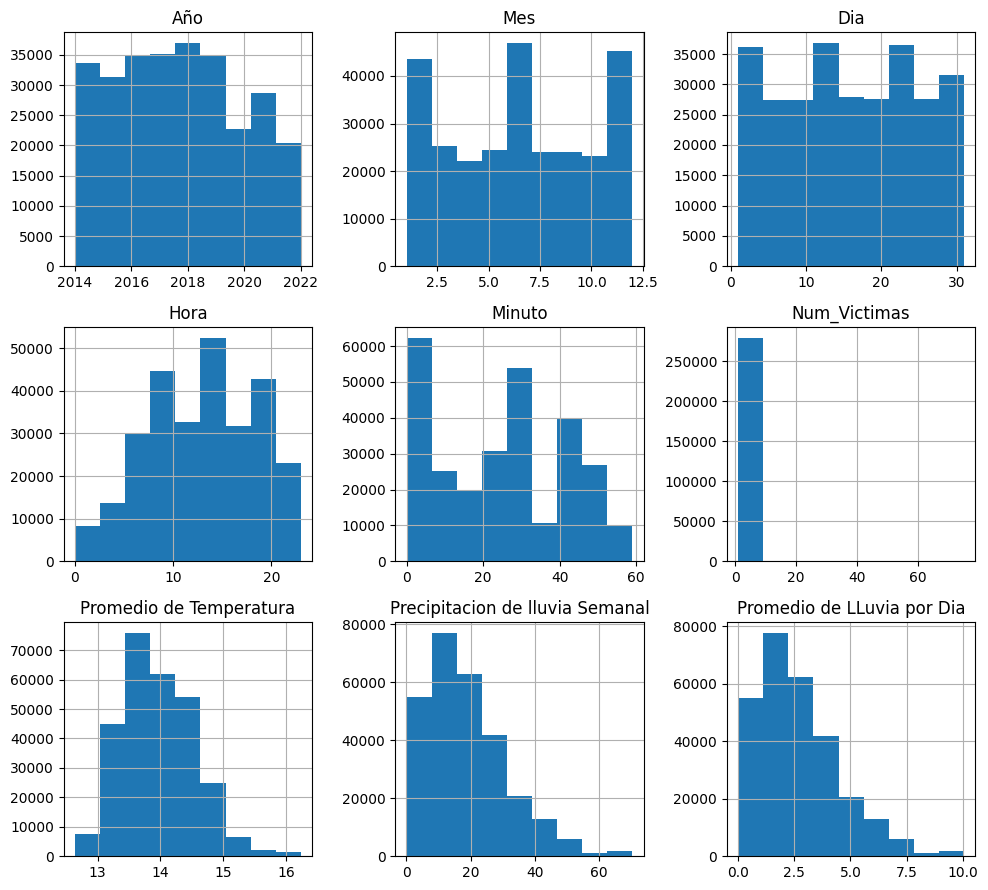

In [ ]:
# Generar el histograma
fig, ax = plt.subplots(figsize=(10,9))
data.hist(ax=ax, bins=9)
plt.tight_layout()
plt.show()

Los gráficos muestran que la distribución temporal de los accidentes es bastante homogénea a lo largo de los años, meses y días, sin concentraciones extremadamente marcadas, aunque se perciben ligeros picos en ciertos periodos. A nivel horario, los accidentes tienden a concentrarse en horas del día, especialmente entre la mañana y la tarde, lo que coincide con mayores niveles de tráfico, mientras que en la madrugada la ocurrencia es considerablemente menor.

En cuanto a las variables asociadas al evento, el número de víctimas presenta una distribución altamente sesgada hacia valores bajos, donde la gran mayoría de los accidentes involucran pocas personas, pero existen algunos casos extremos que generan colas largas en la distribución. Esto confirma la presencia de outliers que podrían afectar análisis estadísticos si no se tratan adecuadamente.

Respecto a las condiciones climáticas, la temperatura muestra una distribución bastante concentrada, lo que indica poca variabilidad en el clima térmico de la ciudad. Por el contrario, las variables de precipitación (semanal y diaria) presentan mayor dispersión y asimetría positiva, lo que sugiere que la lluvia es un factor más variable y potencialmente más influyente en la ocurrencia de accidentes que la temperatura.

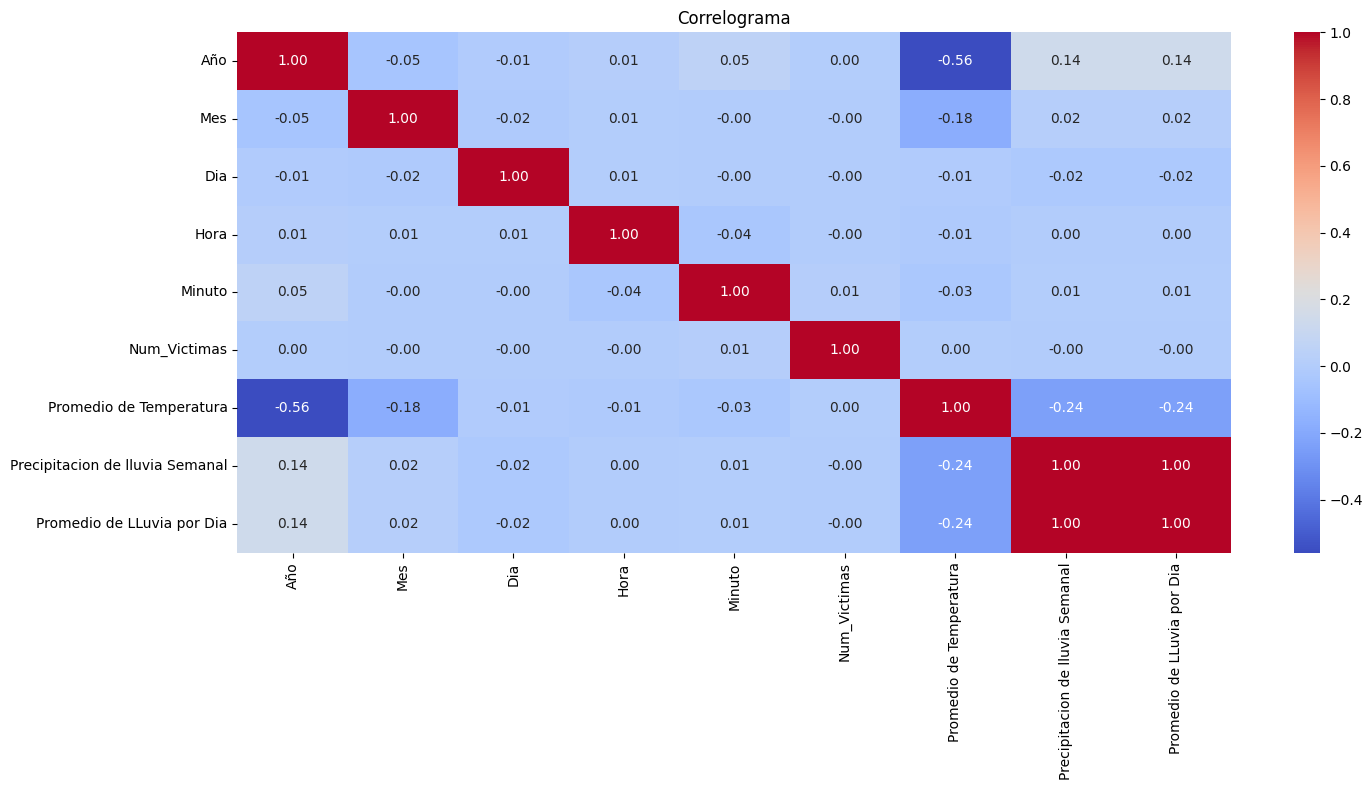

In [ ]:
# Generar el correlograma (heatmap de la matriz de correlaciones)
plt.figure(figsize=(15, 8))
correlation_matrix = data.select_dtypes(include="number").corr()  # Matriz de correlaciones
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlograma')
plt.tight_layout()
plt.show()

El correlograma muestra que la mayoría de las variables presentan correlaciones muy bajas o cercanas a cero, lo que indica que no existen relaciones lineales fuertes entre factores como día, hora, mes o número de víctimas. Esto sugiere que los accidentes no dependen de una sola variable aislada, sino de múltiples factores combinados, lo cual es común en fenómenos complejos como la siniestralidad vial.

Se destaca una correlación negativa moderada entre el año y la temperatura (-0.56), lo que podría reflejar cambios en los registros climáticos a lo largo del tiempo o variaciones en la fuente de datos. Asimismo, la temperatura presenta una relación inversa leve con la precipitación (-0.24), lo cual es coherente desde el punto de vista climático: a mayor lluvia, menor temperatura promedio.

Finalmente, se observa una correlación perfecta (1.00) entre la precipitación semanal y la lluvia promedio diaria, lo que indica que ambas variables contienen prácticamente la misma información. Esto es importante para el modelado, ya que podría generar redundancia o multicolinealidad, por lo que sería recomendable conservar solo una de estas variables en análisis posteriores.

## Preparacion de Datos Modelaje

In [ ]:
# Se usa la base original para realizar los cambios encontrados en el analisis exploratorio
#Creacion de variable Severo
df['Severo']=df['Severidad']!='Solo daños materiales / Ilesos'
df['Severo']

# X
X=df.drop(['ID','Severidad','Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via','Severo','Precipitacion de lluvia Semanal','Fecha'],axis=1)
X=pd.concat([X,pd.get_dummies(df[['Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via']],prefix=['Tipo_Colision','Objeto','Tipo_Objeto','Diseño_Via'],drop_first=True)],axis=1)

# Y
y=df['Severo'].astype(int)

# División de datos (train / test), 80% entrenamiento y 20% prueba donde random_state garantiza reproducibilidad
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=8)



In [ ]:
# Calculamos la información mutua entre cada variable y el target
mu_inf=mutual_info_classif(X_train,y_train,random_state=8,discrete_features='auto')
mu_inf

# Seleccionamos solo variables con información mutua > 0.005
X_train=X_train.iloc[:,mu_inf>0.005]
X_test=X_test.iloc[:,mu_inf>0.005]

# Revisamos las columnas finales seleccionadas
X_train.columns

Index(['Año', 'Hora', 'Minuto', 'Num_Victimas',
       'Tipo_Colision_Caída de ocupante', 'Tipo_Colision_Choque',
       'Tipo_Colision_Vuelco', 'Objeto_No Aplica', 'Objeto_Vehículo',
       'Tipo_Objeto_No Aplica', 'Diseño_Via_Intersección',
       'Diseño_Via_Sección de carretera'],
      dtype='object')

In [ ]:
# Revisamos las columnas finales seleccionadas
# Definimos F1-score como métrica
scorer = make_scorer(f1_score)

## Modelos

### Arboles de Decision

In [ ]:
tree_model= DecisionTreeClassifier(random_state=8)
tree_model=TunedThresholdClassifierCV(tree_model, scoring=scorer)
tree_model.fit(X_train,y_train)

TunedThresholdClassifierCV(estimator=DecisionTreeClassifier(random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

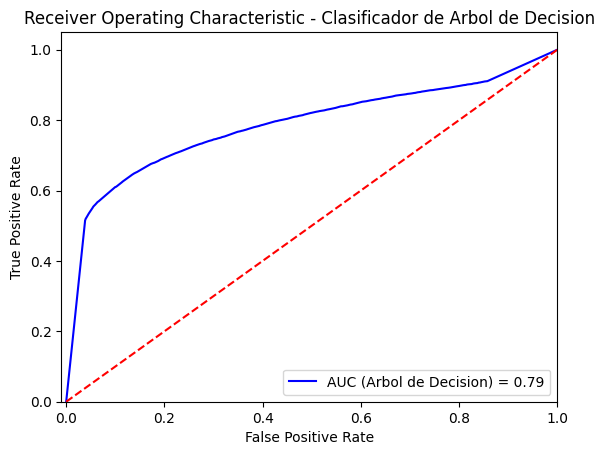

Exactitud: 0.7922904527117884
Precisión: 0.6253511235955056
Especificidad: 0.8851530455648874
AUC: 0.7861252732984507
Matriz de Confusión (Arbol de decision):
[[31723  4116]
 [ 7469 12467]]


In [ ]:
# Realización de predicciones
predicciones_tree = tree_model.predict(X_test)
prediccionesProb_tree = tree_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, prediccionesProb_tree, pos_label=1)
AUC_tree = auc(fpr_tree, tpr_tree)
plt.title('Receiver Operating Characteristic - Clasificador de Arbol de Decision')
plt.plot(fpr_tree, tpr_tree, 'b', label='AUC (Arbol de Decision) = %0.2f' % AUC_tree)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_tree = accuracy_score(y_test, predicciones_tree)
precision_tree = precision_score(y_test, predicciones_tree)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_tree).ravel()
specificity_tree = tn / (tn+fp)
precision_tree = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_tree}')
print(f'Precisión: {precision_tree}')
print(f'Especificidad: {specificity_tree}')
print(f'AUC: {AUC_tree}')

# Matriz de confusión
conf_matrix_tree = confusion_matrix(y_test, predicciones_tree)
print("Matriz de Confusión (Arbol de decision):")
print(conf_matrix_tree)

In [ ]:
y_test.value_counts()

,count
Severo,
0,35839
1,19936


### Bagging

In [ ]:
bag_model= BaggingClassifier(n_estimators=10, random_state=8)
bag_model=TunedThresholdClassifierCV(bag_model, scoring=scorer)
bag_model.fit(X_train,y_train)

TunedThresholdClassifierCV(estimator=BaggingClassifier(random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

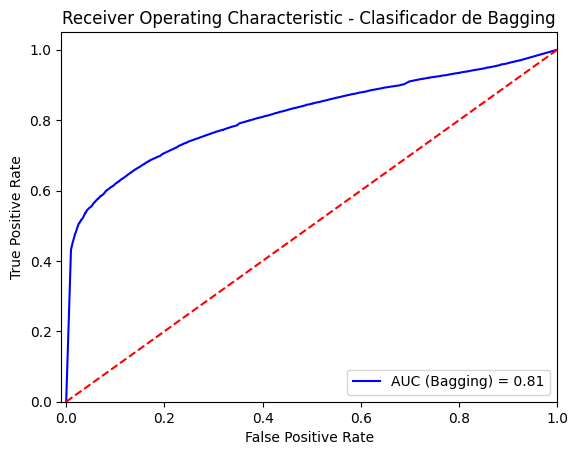

Exactitud: 0.7924518153294486
Precisión: 0.6450140449438202
Especificidad: 0.8744663634588019
AUC: 0.8145808824349416
Matriz de Confusión (Bagging):
[[31340  4499]
 [ 7077 12859]]


In [ ]:
# Realización de predicciones
predicciones_bag = bag_model.predict(X_test)
prediccionesProb_bag = bag_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_bag, tpr_bag, thresholds_bag = roc_curve(y_test, prediccionesProb_bag, pos_label=1)
AUC_bag = auc(fpr_bag, tpr_bag)
plt.title('Receiver Operating Characteristic - Clasificador de Bagging')
plt.plot(fpr_bag, tpr_bag, 'b', label='AUC (Bagging) = %0.2f' % AUC_bag)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_bag = accuracy_score(y_test, predicciones_bag)
precision_bag = precision_score(y_test, predicciones_bag)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_bag).ravel()
specificity_bag = tn / (tn+fp)
precision_bag = tp / (tp+fn)


# Resultados
print(f'Exactitud: {accuracy_bag}')
print(f'Precisión: {precision_bag}')
print(f'Especificidad: {specificity_bag}')
print(f'AUC: {AUC_bag}')

# Matriz de confusión
conf_matrix_bag = confusion_matrix(y_test, predicciones_bag)
print("Matriz de Confusión (Bagging):")
print(conf_matrix_bag)

### Random Forest

In [ ]:
forest_model= RandomForestClassifier(random_state=8)
forest_model=TunedThresholdClassifierCV(forest_model, scoring=scorer)
forest_model.fit(X_train,y_train)

TunedThresholdClassifierCV(estimator=RandomForestClassifier(random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

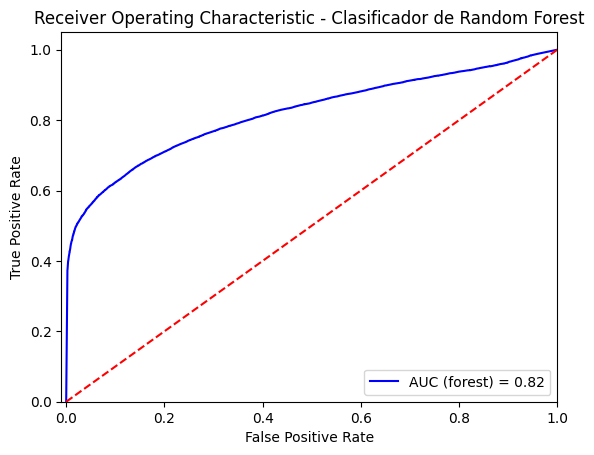

Exactitud: 0.7964500224114747
Precisión: 0.6389446227929374
Especificidad: 0.8840648455593069
AUC: 0.8198455767739952
Matriz de Confusión (forest):
[[31684  4155]
 [ 7198 12738]]


In [ ]:
# Realización de predicciones
predicciones_forest = forest_model.predict(X_test)
prediccionesProb_forest = forest_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, prediccionesProb_forest, pos_label=1)
AUC_forest = auc(fpr_forest, tpr_forest)
plt.title('Receiver Operating Characteristic - Clasificador de Random Forest')
plt.plot(fpr_forest, tpr_forest, 'b', label='AUC (forest) = %0.2f' % AUC_forest)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_forest = accuracy_score(y_test, predicciones_forest)
precision_forest = precision_score(y_test, predicciones_forest)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_forest).ravel()
specificity_forest = tn / (tn+fp)
precision_forest = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_forest}')
print(f'Precisión: {precision_forest}')
print(f'Especificidad: {specificity_forest}')
print(f'AUC: {AUC_forest}')

# Matriz de confusión
conf_matrix_forest = confusion_matrix(y_test, predicciones_forest)
print("Matriz de Confusión (forest):")
print(conf_matrix_forest)

#### Boosting

In [ ]:
boost_model=GradientBoostingClassifier(random_state=8)
boost_model=TunedThresholdClassifierCV(boost_model, scoring=scorer)
boost_model.fit(X_train,y_train)

TunedThresholdClassifierCV(estimator=GradientBoostingClassifier(random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

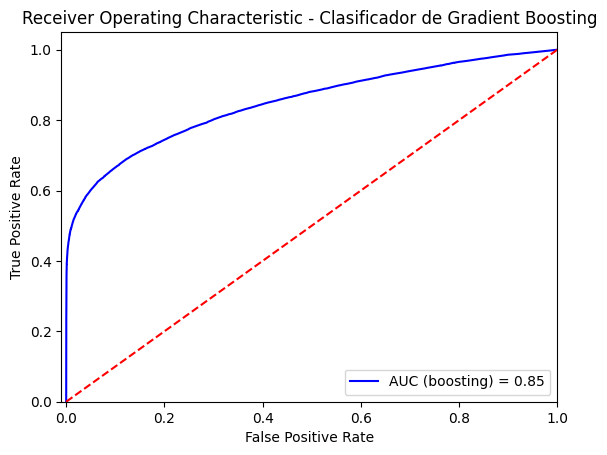

Exactitud: 0.8155804571940833
Precisión: 0.6687901284109149
Especificidad: 0.8972348558832557
AUC: 0.8497641299783404
Matriz de Confusión (boosting):
[[32156  3683]
 [ 6603 13333]]


In [ ]:
# Realización de predicciones
predicciones_boost = boost_model.predict(X_test)
prediccionesProb_boost = boost_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_boost, tpr_boost, thresholds_boost = roc_curve(y_test, prediccionesProb_boost, pos_label=1)
AUC_boost = auc(fpr_boost, tpr_boost)
plt.title('Receiver Operating Characteristic - Clasificador de Gradient Boosting')
plt.plot(fpr_boost, tpr_boost, 'b', label='AUC (boosting) = %0.2f' % AUC_boost)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_boost = accuracy_score(y_test, predicciones_boost)
precision_boost = precision_score(y_test, predicciones_boost)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_boost).ravel()
specificity_boost = tn / (tn+fp)
precision_boost = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_boost}')
print(f'Precisión: {precision_boost}')
print(f'Especificidad: {specificity_boost}')
print(f'AUC: {AUC_boost}')

# Matriz de confusión
conf_matrix_boost = confusion_matrix(y_test, predicciones_boost)
print("Matriz de Confusión (boosting):")
print(conf_matrix_boost)

### Modelo Logistico

In [ ]:
scaler=StandardScaler()
X_train_norm=scaler.fit_transform(X_train)
X_test_norm=scaler.transform(X_test)

In [ ]:
log_model=LogisticRegression(random_state=8,max_iter=1000)
log_model=TunedThresholdClassifierCV(log_model, scoring=scorer)
log_model.fit(X_train_norm,y_train)

TunedThresholdClassifierCV(estimator=LogisticRegression(max_iter=1000,
                                                        random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

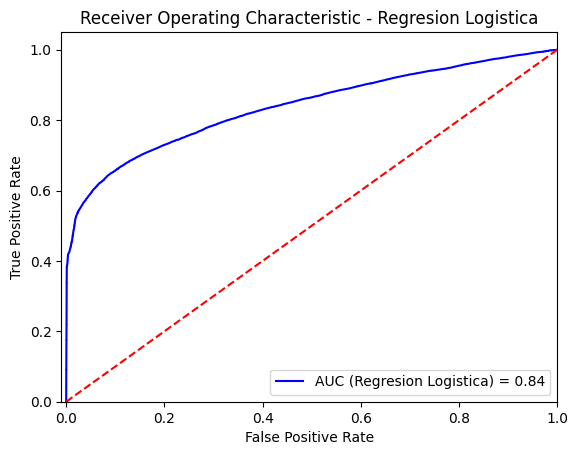

Exactitud: 0.8100941281936351
Precisión: 0.6674859550561798
Especificidad: 0.8894221378944726
AUC: 0.8377434901817237
Matriz de Confusión (Regresion Logistica):
[[31876  3963]
 [ 6629 13307]]


In [ ]:
# Realización de predicciones
predicciones_log = log_model.predict(X_test_norm)
prediccionesProb_log = log_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, prediccionesProb_log, pos_label=1)
AUC_log = auc(fpr_log, tpr_log)
plt.title('Receiver Operating Characteristic - Regresion Logistica')
plt.plot(fpr_log, tpr_log, 'b', label='AUC (Regresion Logistica) = %0.2f' % AUC_log)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_log = accuracy_score(y_test, predicciones_log)
precision_log = precision_score(y_test, predicciones_log)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_log).ravel()
specificity_log = tn / (tn+fp)
precision_log = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_log}')
print(f'Precisión: {precision_log}')
print(f'Especificidad: {specificity_log}')
print(f'AUC: {AUC_log}')

# Matriz de confusión
conf_matrix_log = confusion_matrix(y_test, predicciones_log)
print("Matriz de Confusión (Regresion Logistica):")
print(conf_matrix_log)

### SVM

In [ ]:
svm_df=pd.concat([pd.DataFrame(X_train_norm),y_train.reset_index()],axis=1)
svm_df=svm_df.drop('index',axis=1)
svm_df=svm_df.sample(n=20000,random_state=8)

X_train_svm=svm_df.iloc[:,:-1]
y_train_svm=svm_df.iloc[:,-1]

#### Lineal

In [ ]:
svml_model=SVC(kernel='linear',random_state=8, probability=True)
svml_model=TunedThresholdClassifierCV(svml_model, scoring=scorer)
svml_model.fit(X_train_svm,y_train_svm)

TunedThresholdClassifierCV(estimator=SVC(kernel='linear', probability=True,
                                         random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

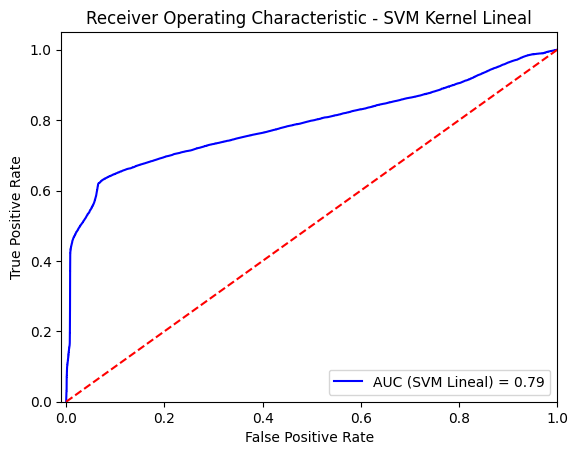

Exactitud: 0.8212102196324518
Precisión: 0.6221408507223114
Especificidad: 0.9319456458048495
AUC: 0.7906486518179641
Matriz de Confusión (SVM Lineal):
[[33400  2439]
 [ 7533 12403]]


In [ ]:
# Realización de predicciones
predicciones_svml = svml_model.predict(X_test_norm)
prediccionesProb_svml = svml_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svml, tpr_svml, thresholds_svml = roc_curve(y_test, prediccionesProb_svml, pos_label=1)
AUC_svml = auc(fpr_svml, tpr_svml)
plt.title('Receiver Operating Characteristic - SVM Kernel Lineal')
plt.plot(fpr_svml, tpr_svml, 'b', label='AUC (SVM Lineal) = %0.2f' % AUC_svml)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svml = accuracy_score(y_test, predicciones_svml)
precision_svml = precision_score(y_test, predicciones_svml)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svml).ravel()
specificity_svml = tn / (tn+fp)
precision_svml = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svml}')
print(f'Precisión: {precision_svml}')
print(f'Especificidad: {specificity_svml}')
print(f'AUC: {AUC_svml}')

# Matriz de confusión
conf_matrix_svml = confusion_matrix(y_test, predicciones_svml)
print("Matriz de Confusión (SVM Lineal):")
print(conf_matrix_svml)

#### Radial

In [ ]:
svmr_model=SVC(kernel='rbf',random_state=8, probability=True)
svmr_model=TunedThresholdClassifierCV(svmr_model, scoring=scorer)
svmr_model.fit(X_train_svm,y_train_svm)

TunedThresholdClassifierCV(estimator=SVC(probability=True, random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

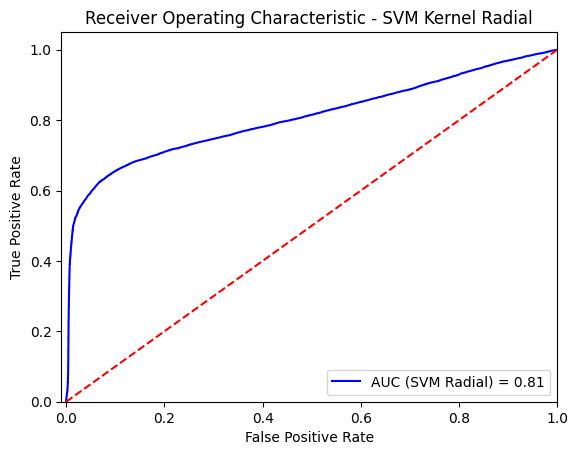

Exactitud: 0.8207082025997311
Precisión: 0.6289626805778491
Especificidad: 0.9273696252685621
AUC: 0.8079327864904742
Matriz de Confusión (SVM Radial):
[[33236  2603]
 [ 7397 12539]]


In [ ]:
# Realización de predicciones
predicciones_svmr = svmr_model.predict(X_test_norm)
prediccionesProb_svmr = svmr_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svmr, tpr_svmr, thresholds_svmr = roc_curve(y_test, prediccionesProb_svmr, pos_label=1)
AUC_svmr = auc(fpr_svmr, tpr_svmr)
plt.title('Receiver Operating Characteristic - SVM Kernel Radial')
plt.plot(fpr_svmr, tpr_svmr, 'b', label='AUC (SVM Radial) = %0.2f' % AUC_svmr)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svmr = accuracy_score(y_test, predicciones_svmr)
precision_svmr = precision_score(y_test, predicciones_svmr)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svmr).ravel()
specificity_svmr = tn / (tn+fp)
precision_svmr = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svmr}')
print(f'Precisión: {precision_svmr}')
print(f'Especificidad: {specificity_svmr}')
print(f'AUC: {AUC_svmr}')

# Matriz de confusión
conf_matrix_svmr = confusion_matrix(y_test, predicciones_svmr)
print("Matriz de Confusión (SVM Radial):")
print(conf_matrix_svmr)

#### Polinomial

In [ ]:
svmp_model=SVC(kernel='poly',random_state=8, probability=True, degree=2)
svmp_model=TunedThresholdClassifierCV(svmp_model, scoring=scorer)
svmp_model.fit(X_train_svm,y_train_svm)

TunedThresholdClassifierCV(estimator=SVC(degree=2, kernel='poly',
                                         probability=True, random_state=8),
                           scoring=make_scorer(f1_score, response_method='predict'))

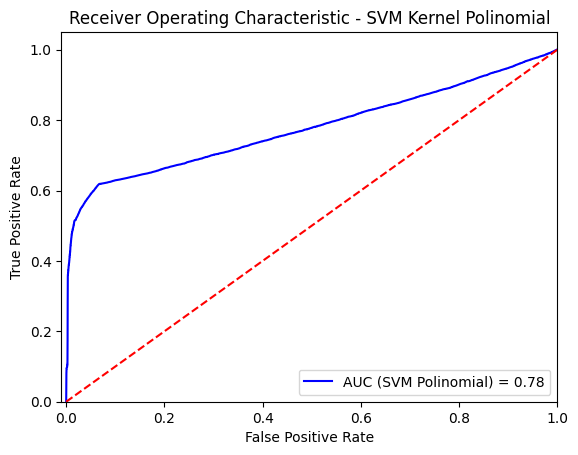

Exactitud: 0.8206185567010309
Precisión: 0.6181781701444623
Especificidad: 0.9332291637601495
AUC: 0.7779197857094262
Matriz de Confusión (SVM Polinomial):
[[33446  2393]
 [ 7612 12324]]


In [ ]:
# Realización de predicciones
predicciones_svmp = svmp_model.predict(X_test_norm)
prediccionesProb_svmp = svmp_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svmp, tpr_svmp, thresholds_svmp = roc_curve(y_test, prediccionesProb_svmp, pos_label=1)
AUC_svmp = auc(fpr_svmp, tpr_svmp)
plt.title('Receiver Operating Characteristic - SVM Kernel Polinomial')
plt.plot(fpr_svmp, tpr_svmp, 'b', label='AUC (SVM Polinomial) = %0.2f' % AUC_svmp)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svmp = accuracy_score(y_test, predicciones_svmp)
precision_svmp = precision_score(y_test, predicciones_svmp)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svmp).ravel()
specificity_svmp = tn / (tn+fp)
precision_svmp = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svmp}')
print(f'Precisión: {precision_svmp}')
print(f'Especificidad: {specificity_svmp}')
print(f'AUC: {AUC_svmp}')

# Matriz de confusión
conf_matrix_svmp = confusion_matrix(y_test, predicciones_svmp)
print("Matriz de Confusión (SVM Polinomial):")
print(conf_matrix_svmp)

### Graficos

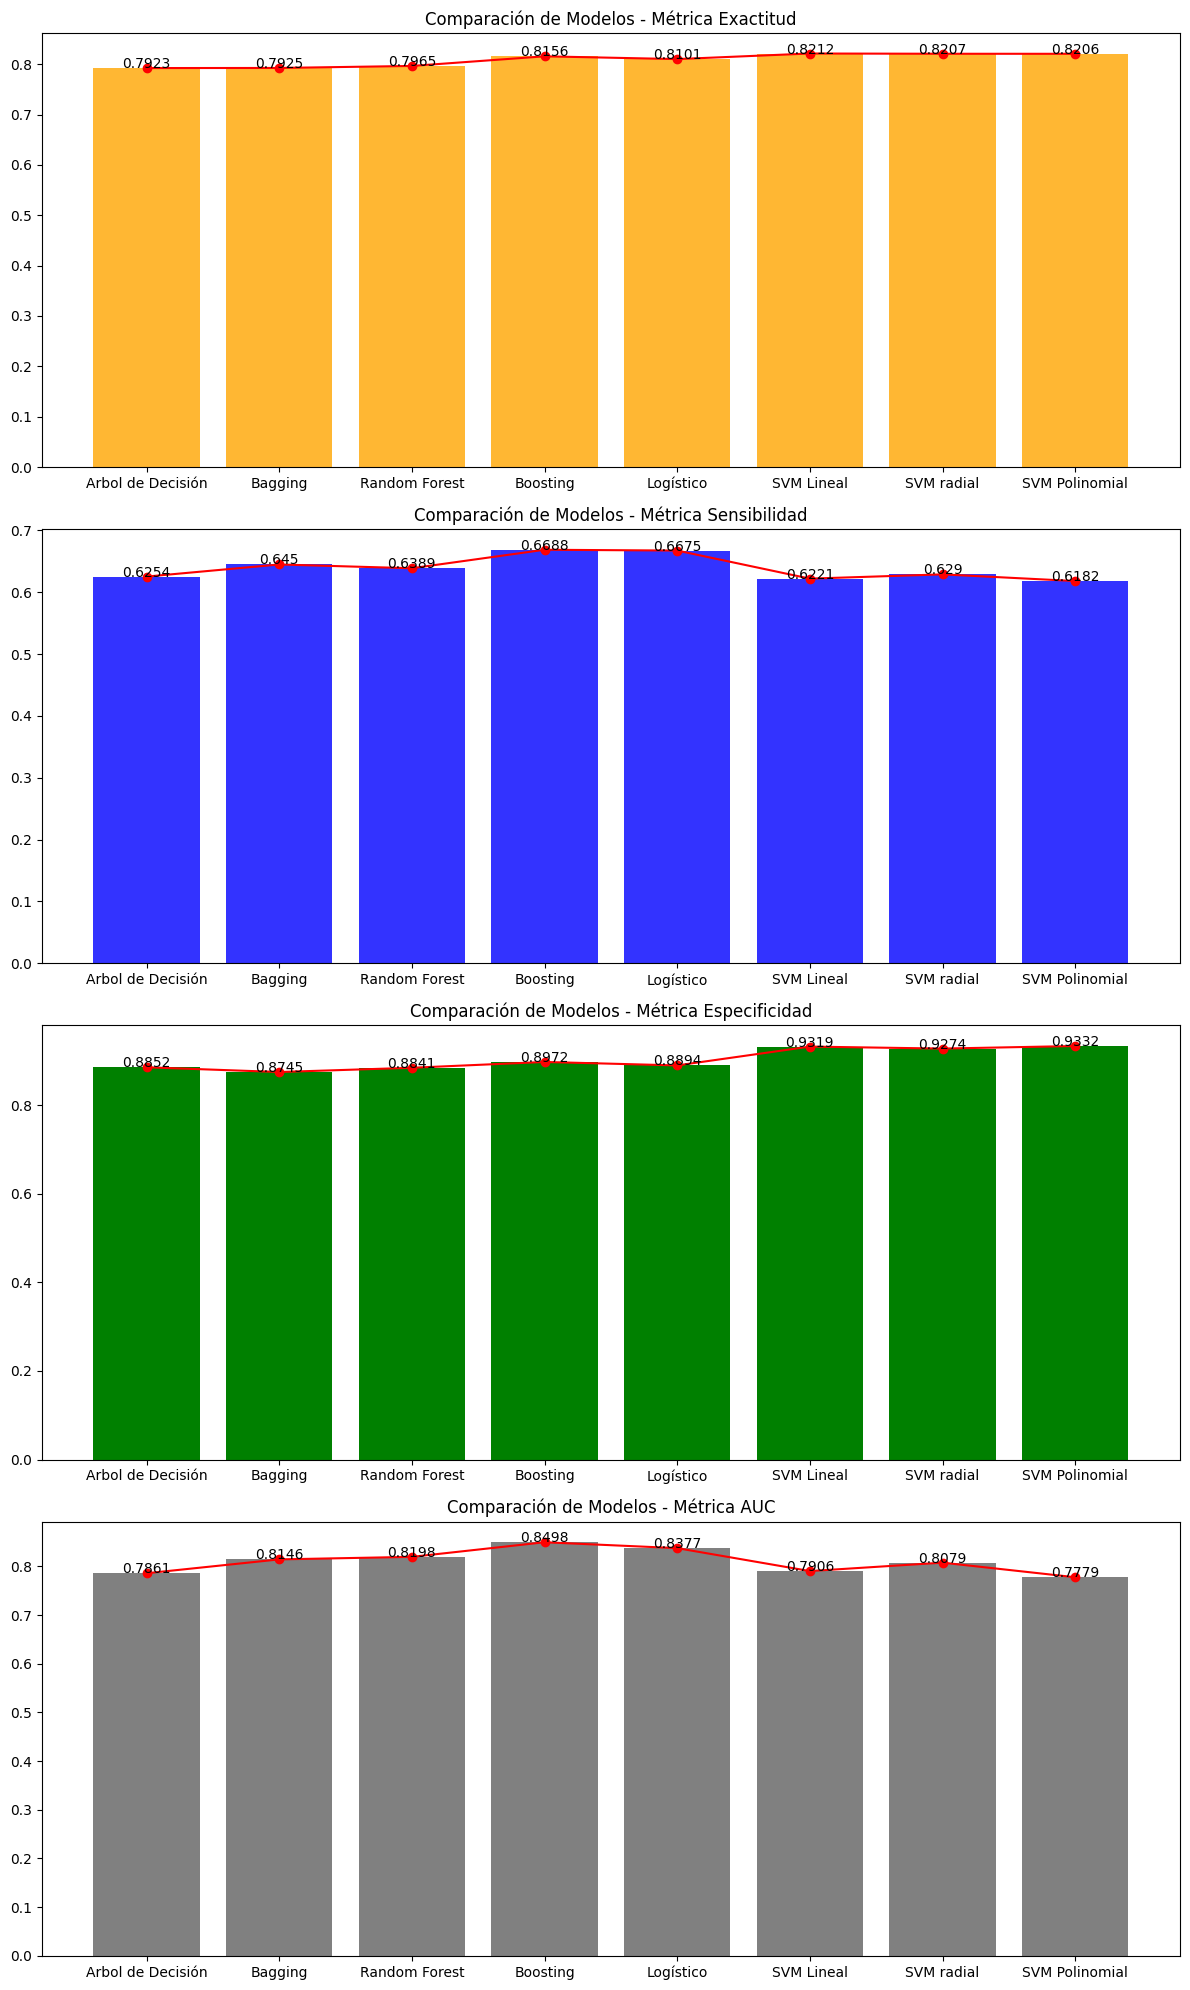

In [ ]:
# Construcción de Gráficas Comparativas
fig = plt.figure(figsize=(12,20))  # Ajuste del tamaño para una sola columna

def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i, y[i], y[i], ha='center')

# Primer gráfico - Exactitud
ax1 = plt.subplot(4,1,1)  # Cambiado para una sola columna de 3 filas

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(accuracy_tree,4),round(accuracy_bag,4),round(accuracy_forest,4),
  round(accuracy_boost,4), round(accuracy_log,4),round(accuracy_svml,4),round(accuracy_svmr,4),round(accuracy_svmp,4)]
ax1.bar(ejeX,ejeY,color='orange', alpha = 0.8)
ax1.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax1)

ax1.set_title("Comparación de Modelos - Métrica Exactitud")  # Título específico del subplot

# Segundo gráfico - Precisión
ax2 = plt.subplot(4,1,2)  # Ajustado para el segundo gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(precision_tree,4),round(precision_bag,4),round(precision_forest,4),
  round(precision_boost,4), round(precision_log,4),round(precision_svml,4),round(precision_svmr,4),round(precision_svmp,4)]
ax2.bar(ejeX,ejeY,color='blue', alpha = 0.8)
ax2.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax2)

ax2.set_title("Comparación de Modelos - Métrica Sensibilidad")  # Título específico del subplot


# Tercer gráfico - Especificidad
ax3 = plt.subplot(4,1,3)  # Ajustado para el tercer gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(specificity_tree,4),round(specificity_bag,4),round(specificity_forest,4),
  round(specificity_boost,4), round(specificity_log,4),round(specificity_svml,4),round(specificity_svmr,4),round(specificity_svmp,4)]
ax3.bar(ejeX,ejeY,color='g')
ax3.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax3)

ax3.set_title("Comparación de Modelos - Métrica Especificidad")  # Título específico del subplot

# Cuarto gráfico - AUC
ax4 = plt.subplot(4,1,4)  # Ajustado para el tercer gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(AUC_tree,4),round(AUC_bag,4),round(AUC_forest,4),
  round(AUC_boost,4), round(AUC_log,4),round(AUC_svml,4),round(AUC_svmr,4),round(AUC_svmp,4)]
ax4.bar(ejeX,ejeY,color='grey')
ax4.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax4)

ax4.set_title("Comparación de Modelos - Métrica AUC")  # Título específico del subplot



plt.tight_layout()  # Ajusta automáticamente los subplots para que no se solapen
plt.show()

## Modelos Balanceados

In [ ]:
X_train,y_train=SMOTE(random_state=8,sampling_strategy='minority').fit_resample(X_train,y_train)
pd.value_counts(y_train)

/tmp/ipykernel_67553/1710812258.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(y_train)


,count
Severo,
0,143302
1,143302


#### Arboles de Decision

In [ ]:
tree_model= DecisionTreeClassifier(random_state=8)
tree_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=8)

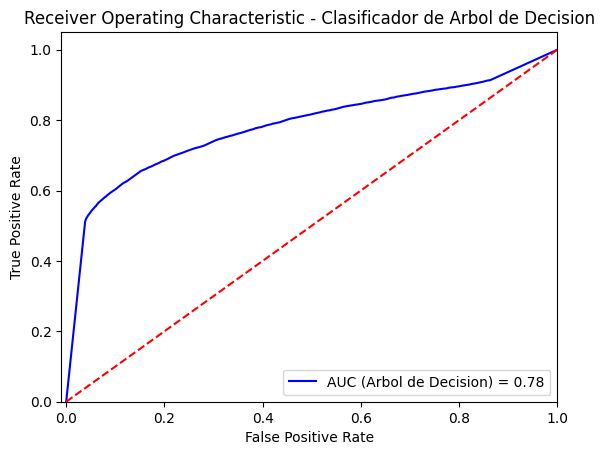

Exactitud: 0.7871447781264007
Precisión: 0.6262038523274478
Especificidad: 0.8766706660342085
AUC: 0.7828085400220632
Matriz de Confusión (Arbol de decision):
[[31419  4420]
 [ 7452 12484]]


In [ ]:
# Realización de predicciones
predicciones_tree = tree_model.predict(X_test)
prediccionesProb_tree = tree_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, prediccionesProb_tree, pos_label=1)
AUC_tree = auc(fpr_tree, tpr_tree)
plt.title('Receiver Operating Characteristic - Clasificador de Arbol de Decision')
plt.plot(fpr_tree, tpr_tree, 'b', label='AUC (Arbol de Decision) = %0.2f' % AUC_tree)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_tree = accuracy_score(y_test, predicciones_tree)
precision_tree = precision_score(y_test, predicciones_tree)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_tree).ravel()
specificity_tree = tn / (tn+fp)
precision_tree = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_tree}')
print(f'Precisión: {precision_tree}')
print(f'Especificidad: {specificity_tree}')
print(f'AUC: {AUC_tree}')

# Matriz de confusión
conf_matrix_tree = confusion_matrix(y_test, predicciones_tree)
print("Matriz de Confusión (Arbol de decision):")
print(conf_matrix_tree)

In [ ]:
y_test.value_counts()

,count
Severo,
0,35839
1,19936


#### Bagging

In [ ]:
bag_model= BaggingClassifier(n_estimators=10, random_state=8)
bag_model.fit(X_train,y_train)

BaggingClassifier(random_state=8)

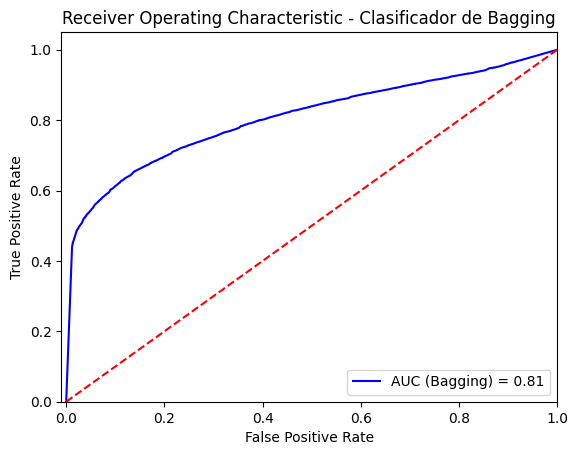

Exactitud: 0.7877902285970417
Precisión: 0.6470204654895666
Especificidad: 0.8660955941851056
AUC: 0.8072635399320405
Matriz de Confusión (Bagging):
[[31040  4799]
 [ 7037 12899]]


In [ ]:
# Realización de predicciones
predicciones_bag = bag_model.predict(X_test)
prediccionesProb_bag = bag_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_bag, tpr_bag, thresholds_bag = roc_curve(y_test, prediccionesProb_bag, pos_label=1)
AUC_bag = auc(fpr_bag, tpr_bag)
plt.title('Receiver Operating Characteristic - Clasificador de Bagging')
plt.plot(fpr_bag, tpr_bag, 'b', label='AUC (Bagging) = %0.2f' % AUC_bag)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_bag = accuracy_score(y_test, predicciones_bag)
precision_bag = precision_score(y_test, predicciones_bag)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_bag).ravel()
specificity_bag = tn / (tn+fp)
precision_bag = tp / (tp+fn)


# Resultados
print(f'Exactitud: {accuracy_bag}')
print(f'Precisión: {precision_bag}')
print(f'Especificidad: {specificity_bag}')
print(f'AUC: {AUC_bag}')

# Matriz de confusión
conf_matrix_bag = confusion_matrix(y_test, predicciones_bag)
print("Matriz de Confusión (Bagging):")
print(conf_matrix_bag)

#### Random Forest

In [ ]:
forest_model= RandomForestClassifier(random_state=8)
forest_model.fit(X_train,y_train)

RandomForestClassifier(random_state=8)

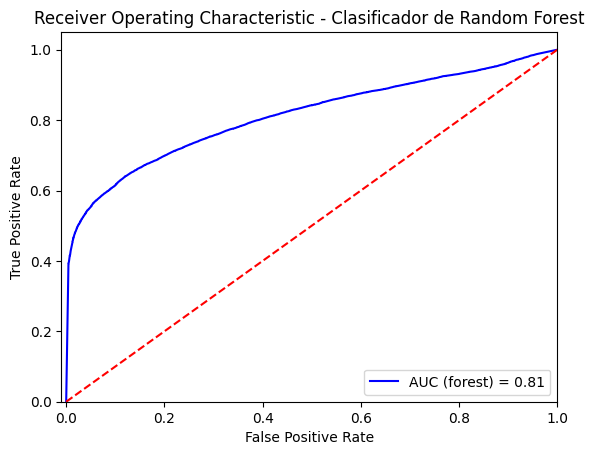

Exactitud: 0.7894755714926042
Precisión: 0.6520365168539326
Especificidad: 0.8659281787996317
AUC: 0.8122075983138789
Matriz de Confusión (forest):
[[31034  4805]
 [ 6937 12999]]


In [ ]:
# Realización de predicciones
predicciones_forest = forest_model.predict(X_test)
prediccionesProb_forest = forest_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, prediccionesProb_forest, pos_label=1)
AUC_forest = auc(fpr_forest, tpr_forest)
plt.title('Receiver Operating Characteristic - Clasificador de Random Forest')
plt.plot(fpr_forest, tpr_forest, 'b', label='AUC (forest) = %0.2f' % AUC_forest)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_forest = accuracy_score(y_test, predicciones_forest)
precision_forest = precision_score(y_test, predicciones_forest)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_forest).ravel()
specificity_forest = tn / (tn+fp)
precision_forest = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_forest}')
print(f'Precisión: {precision_forest}')
print(f'Especificidad: {specificity_forest}')
print(f'AUC: {AUC_forest}')

# Matriz de confusión
conf_matrix_forest = confusion_matrix(y_test, predicciones_forest)
print("Matriz de Confusión (forest):")
print(conf_matrix_forest)

#### Boosting

In [ ]:
boost_model=GradientBoostingClassifier(random_state=8)
boost_model.fit(X_train,y_train)

GradientBoostingClassifier(random_state=8)

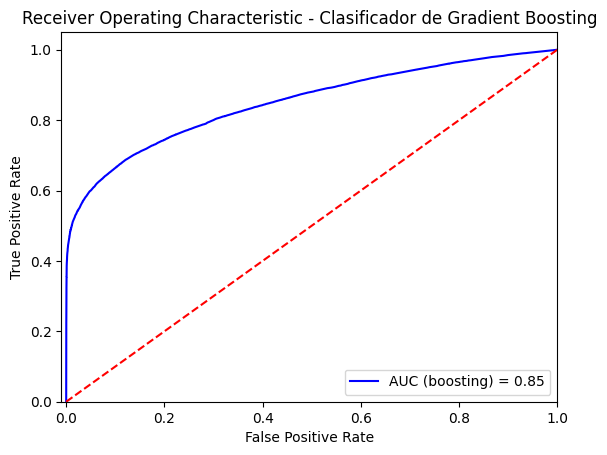

Exactitud: 0.8162976243836845
Precisión: 0.6616673354735152
Especificidad: 0.9023131225759647
AUC: 0.8492812648792216
Matriz de Confusión (boosting):
[[32338  3501]
 [ 6745 13191]]


In [ ]:
# Realización de predicciones
predicciones_boost = boost_model.predict(X_test)
prediccionesProb_boost = boost_model.predict_proba(X_test)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_boost, tpr_boost, thresholds_boost = roc_curve(y_test, prediccionesProb_boost, pos_label=1)
AUC_boost = auc(fpr_boost, tpr_boost)
plt.title('Receiver Operating Characteristic - Clasificador de Gradient Boosting')
plt.plot(fpr_boost, tpr_boost, 'b', label='AUC (boosting) = %0.2f' % AUC_boost)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_boost = accuracy_score(y_test, predicciones_boost)
precision_boost = precision_score(y_test, predicciones_boost)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_boost).ravel()
specificity_boost = tn / (tn+fp)
precision_boost = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_boost}')
print(f'Precisión: {precision_boost}')
print(f'Especificidad: {specificity_boost}')
print(f'AUC: {AUC_boost}')

# Matriz de confusión
conf_matrix_boost = confusion_matrix(y_test, predicciones_boost)
print("Matriz de Confusión (boosting):")
print(conf_matrix_boost)

### Modelo Logistico

In [ ]:
scaler=StandardScaler()
X_train_norm=scaler.fit_transform(X_train)
X_test_norm=scaler.transform(X_test)

In [ ]:
log_model=LogisticRegression(random_state=8,max_iter=1000)
log_model.fit(X_train_norm,y_train)

LogisticRegression(max_iter=1000, random_state=8)

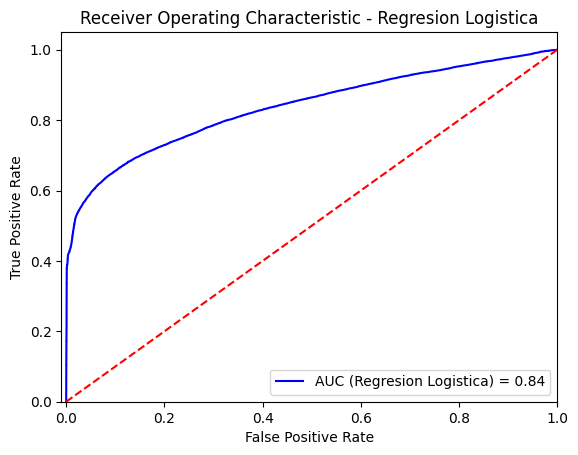

Exactitud: 0.8098610488570148
Precisión: 0.6653792134831461
Especificidad: 0.8902313122575964
AUC: 0.836925927974121
Matriz de Confusión (Regresion Logistica):
[[31905  3934]
 [ 6671 13265]]


In [ ]:
# Realización de predicciones
predicciones_log = log_model.predict(X_test_norm)
prediccionesProb_log = log_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, prediccionesProb_log, pos_label=1)
AUC_log = auc(fpr_log, tpr_log)
plt.title('Receiver Operating Characteristic - Regresion Logistica')
plt.plot(fpr_log, tpr_log, 'b', label='AUC (Regresion Logistica) = %0.2f' % AUC_log)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_log = accuracy_score(y_test, predicciones_log)
precision_log = precision_score(y_test, predicciones_log)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_log).ravel()
specificity_log = tn / (tn+fp)
precision_log = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_log}')
print(f'Precisión: {precision_log}')
print(f'Especificidad: {specificity_log}')
print(f'AUC: {AUC_log}')

# Matriz de confusión
conf_matrix_log = confusion_matrix(y_test, predicciones_log)
print("Matriz de Confusión (Regresion Logistica):")
print(conf_matrix_log)

### SVM

In [ ]:
svm_df=pd.concat([pd.DataFrame(X_train_norm),y_train.reset_index()],axis=1)
svm_df=svm_df.drop('index',axis=1)
svm_df=svm_df.sample(n=20000,random_state=8)

X_train_svm=svm_df.iloc[:,:-1]
y_train_svm=svm_df.iloc[:,-1]

#### Lineal

In [ ]:
svml_model=SVC(kernel='linear',random_state=8, probability=True)
svml_model.fit(X_train_svm,y_train_svm)

SVC(kernel='linear', probability=True, random_state=8)

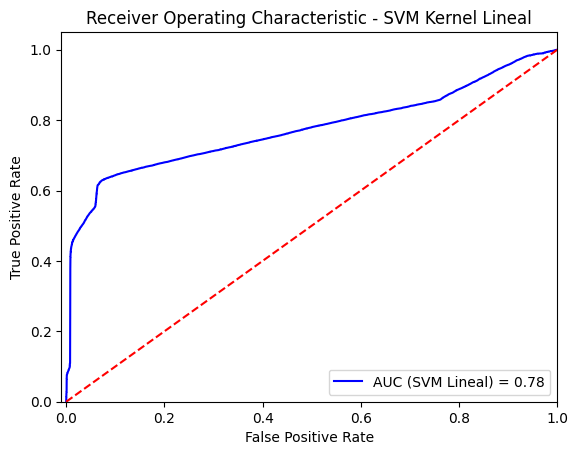

Exactitud: 0.8178216046615867
Precisión: 0.6328250401284109
Especificidad: 0.9207288149780964
AUC: 0.7752995514382877
Matriz de Confusión (SVM Lineal):
[[32998  2841]
 [ 7320 12616]]


In [ ]:
# Realización de predicciones
predicciones_svml = svml_model.predict(X_test_norm)
prediccionesProb_svml = svml_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svml, tpr_svml, thresholds_svml = roc_curve(y_test, prediccionesProb_svml, pos_label=1)
AUC_svml = auc(fpr_svml, tpr_svml)
plt.title('Receiver Operating Characteristic - SVM Kernel Lineal')
plt.plot(fpr_svml, tpr_svml, 'b', label='AUC (SVM Lineal) = %0.2f' % AUC_svml)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svml = accuracy_score(y_test, predicciones_svml)
precision_svml = precision_score(y_test, predicciones_svml)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svml).ravel()
specificity_svml = tn / (tn+fp)
precision_svml = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svml}')
print(f'Precisión: {precision_svml}')
print(f'Especificidad: {specificity_svml}')
print(f'AUC: {AUC_svml}')

# Matriz de confusión
conf_matrix_svml = confusion_matrix(y_test, predicciones_svml)
print("Matriz de Confusión (SVM Lineal):")
print(conf_matrix_svml)

#### Radial

In [ ]:
svmr_model=SVC(kernel='rbf',random_state=8, probability=True)
svmr_model.fit(X_train_svm,y_train_svm)

SVC(probability=True, random_state=8)

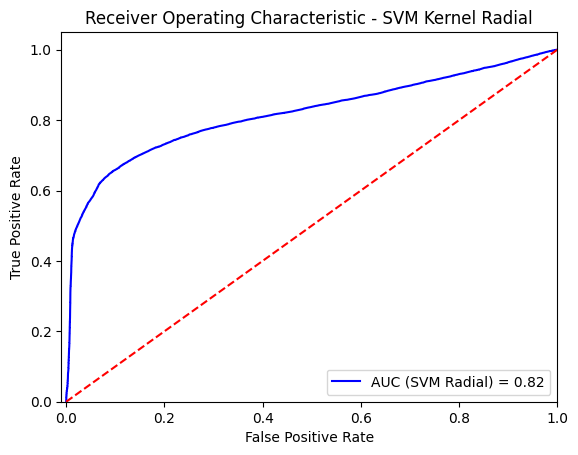

Exactitud: 0.8176064545047064
Precisión: 0.6433085874799358
Especificidad: 0.9145623482798069
AUC: 0.81848096979057
Matriz de Confusión (SVM Radial):
[[32777  3062]
 [ 7111 12825]]


In [ ]:
# Realización de predicciones
predicciones_svmr = svmr_model.predict(X_test_norm)
prediccionesProb_svmr = svmr_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svmr, tpr_svmr, thresholds_svmr = roc_curve(y_test, prediccionesProb_svmr, pos_label=1)
AUC_svmr = auc(fpr_svmr, tpr_svmr)
plt.title('Receiver Operating Characteristic - SVM Kernel Radial')
plt.plot(fpr_svmr, tpr_svmr, 'b', label='AUC (SVM Radial) = %0.2f' % AUC_svmr)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svmr = accuracy_score(y_test, predicciones_svmr)
precision_svmr = precision_score(y_test, predicciones_svmr)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svmr).ravel()
specificity_svmr = tn / (tn+fp)
precision_svmr = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svmr}')
print(f'Precisión: {precision_svmr}')
print(f'Especificidad: {specificity_svmr}')
print(f'AUC: {AUC_svmr}')

# Matriz de confusión
conf_matrix_svmr = confusion_matrix(y_test, predicciones_svmr)
print("Matriz de Confusión (SVM Radial):")
print(conf_matrix_svmr)

#### Polinomial

In [ ]:
svmp_model=SVC(kernel='poly',random_state=8, probability=True, degree=2)
svmp_model.fit(X_train_svm,y_train_svm)

SVC(degree=2, kernel='poly', probability=True, random_state=8)

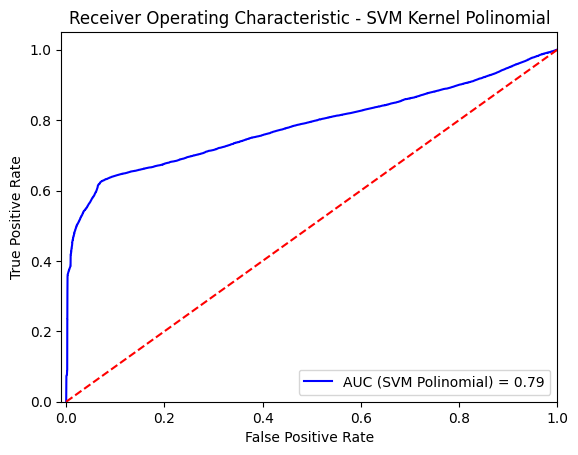

Exactitud: 0.8204392649036306
Precisión: 0.6207363563402889
Especificidad: 0.9315271073411646
AUC: 0.7851884974690851
Matriz de Confusión (SVM Polinomial):
[[33385  2454]
 [ 7561 12375]]


In [ ]:
# Realización de predicciones
predicciones_svmp = svmp_model.predict(X_test_norm)
prediccionesProb_svmp = svmp_model.predict_proba(X_test_norm)[:, 1]

# Evaluación de la curva ROC y el AUC
fpr_svmp, tpr_svmp, thresholds_svmp = roc_curve(y_test, prediccionesProb_svmp, pos_label=1)
AUC_svmp = auc(fpr_svmp, tpr_svmp)
plt.title('Receiver Operating Characteristic - SVM Kernel Polinomial')
plt.plot(fpr_svmp, tpr_svmp, 'b', label='AUC (SVM Polinomial) = %0.2f' % AUC_svmp)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1])
plt.ylim([0, 1.05])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# Estimación de métricas de desempeño
accuracy_svmp = accuracy_score(y_test, predicciones_svmp)
precision_svmp = precision_score(y_test, predicciones_svmp)
tn, fp, fn, tp = confusion_matrix(y_test, predicciones_svmp).ravel()
specificity_svmp = tn / (tn+fp)
precision_svmp = tp / (tp+fn)

# Resultados
print(f'Exactitud: {accuracy_svmp}')
print(f'Precisión: {precision_svmp}')
print(f'Especificidad: {specificity_svmp}')
print(f'AUC: {AUC_svmp}')

# Matriz de confusión
conf_matrix_svmp = confusion_matrix(y_test, predicciones_svmp)
print("Matriz de Confusión (SVM Polinomial):")
print(conf_matrix_svmp)

### Graficos

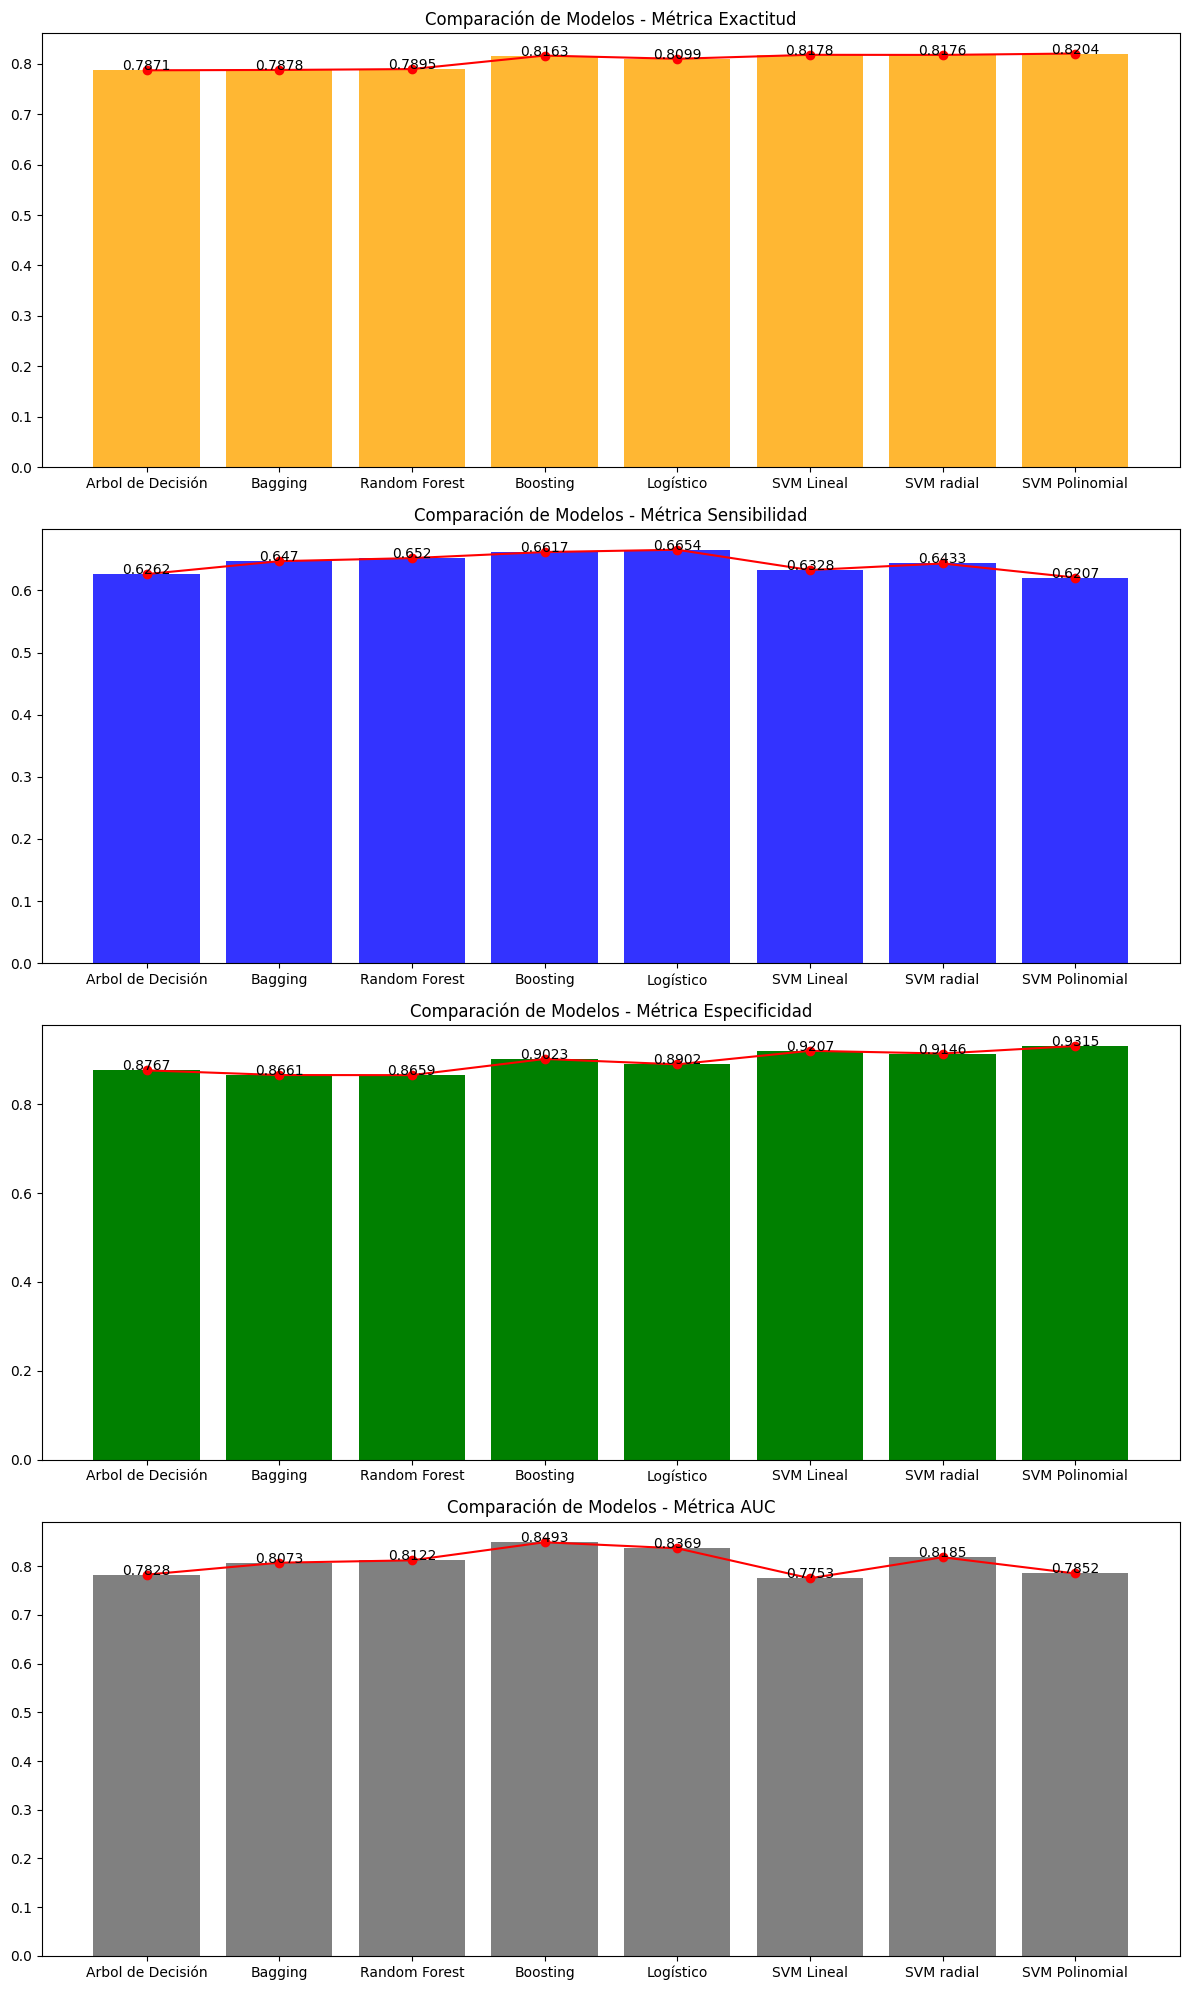

In [ ]:
# Construcción de Gráficas Comparativas
fig = plt.figure(figsize=(12,20))  # Ajuste del tamaño para una sola columna

def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i, y[i], y[i], ha='center')

# Primer gráfico - Exactitud
ax1 = plt.subplot(4,1,1)  # Cambiado para una sola columna de 3 filas

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(accuracy_tree,4),round(accuracy_bag,4),round(accuracy_forest,4),
  round(accuracy_boost,4), round(accuracy_log,4),round(accuracy_svml,4),round(accuracy_svmr,4),round(accuracy_svmp,4)]
ax1.bar(ejeX,ejeY,color='orange', alpha = 0.8)
ax1.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax1)

ax1.set_title("Comparación de Modelos - Métrica Exactitud")  # Título específico del subplot

# Segundo gráfico - Precisión
ax2 = plt.subplot(4,1,2)  # Ajustado para el segundo gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(precision_tree,4),round(precision_bag,4),round(precision_forest,4),
  round(precision_boost,4), round(precision_log,4),round(precision_svml,4),round(precision_svmr,4),round(precision_svmp,4)]
ax2.bar(ejeX,ejeY,color='blue', alpha = 0.8)
ax2.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax2)

ax2.set_title("Comparación de Modelos - Métrica Sensibilidad")  # Título específico del subplot


# Tercer gráfico - Especificidad
ax3 = plt.subplot(4,1,3)  # Ajustado para el tercer gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(specificity_tree,4),round(specificity_bag,4),round(specificity_forest,4),
  round(specificity_boost,4), round(specificity_log,4),round(specificity_svml,4),round(specificity_svmr,4),round(specificity_svmp,4)]
ax3.bar(ejeX,ejeY,color='g')
ax3.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax3)

ax3.set_title("Comparación de Modelos - Métrica Especificidad")  # Título específico del subplot

# Cuarto gráfico - AUC
ax4 = plt.subplot(4,1,4)  # Ajustado para el tercer gráfico en la columna

ejeX = [
  'Arbol de Decisión','Bagging','Random Forest',
  'Boosting','Logístico',"SVM Lineal","SVM radial","SVM Polinomial"]
ejeY = [
  round(AUC_tree,4),round(AUC_bag,4),round(AUC_forest,4),
  round(AUC_boost,4), round(AUC_log,4),round(AUC_svml,4),round(AUC_svmr,4),round(AUC_svmp,4)]
ax4.bar(ejeX,ejeY,color='grey')
ax4.plot(ejeX,ejeY,marker='o', color= 'red')
addlabels(ejeX,ejeY,ax4)

ax4.set_title("Comparación de Modelos - Métrica AUC")  # Título específico del subplot



plt.tight_layout()  # Ajusta automáticamente los subplots para que no se solapen
plt.show()